# РК1. Вариант 9

## Поседкин Никита Михайлович ИУ5-21М

**Задача №9.** Устранение пропусков методом заполнения «хвостом распределения» для одного числового признака.

**Задача №29.** Удаление константных и псевдоконстантных признаков.

**Дополнительно.** Диаграмма рассеяния для пары признаков.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold

%matplotlib inline
sns.set(style="ticks")
np.random.seed(42)

## Генерация набора данных

Генерируем синтетический медицинский датасет (500 пациентов) с колонками:
- `age` — возраст пациента (лет)
- `systolic_bp` — систолическое артериальное давление (мм рт. ст.) — **числовой признак с пропусками**
- `bmi` — индекс массы тела
- `glucose` — уровень глюкозы в крови (мг/дл), правосторонний хвост
- `heart_rate` — частота сердечных сокращений (уд/мин)
- `region_code` — код региона (константный признак, все = 1)
- `test_version` — версия теста (псевдоконстантный: 97% значений = 1, остальные = 2)
- `hospital_flag` — флаг клиники (псевдоконстантный: 96% = 0)
- `diagnosis` — целевой признак: наличие заболевания (0/1)

In [2]:
n = 500

age        = np.random.randint(20, 80, size=n)
systolic_bp = np.random.normal(loc=130, scale=20, size=n).clip(80, 220)
bmi        = np.random.normal(loc=27, scale=5, size=n).clip(15, 50)
glucose    = np.random.exponential(scale=40, size=n) + 70   # правосторонний хвост
heart_rate = np.random.normal(loc=75, scale=12, size=n).clip(45, 130)

# Константный и псевдоконстантные признаки
region_code  = np.ones(n, dtype=int)                                        # всегда 1
test_version = np.where(np.random.rand(n) < 0.97, 1, 2).astype(int)        # 97% = 1
hospital_flag = np.where(np.random.rand(n) < 0.96, 0, 1).astype(int)       # 96% = 0

diagnosis  = (0.3*(age > 55) + 0.4*(systolic_bp > 140) +
              0.3*(glucose > 110) > 0.4).astype(int)

# Вносим пропуски (~15%) в systolic_bp
miss_idx = np.random.choice(n, size=int(n * 0.15), replace=False)
systolic_bp_with_na = systolic_bp.copy().astype(float)
systolic_bp_with_na[miss_idx] = np.nan

df = pd.DataFrame({
    'age': age,
    'systolic_bp': systolic_bp_with_na,
    'bmi': bmi,
    'glucose': glucose,
    'heart_rate': heart_rate,
    'region_code': region_code,
    'test_version': test_version,
    'hospital_flag': hospital_flag,
    'diagnosis': diagnosis
})

df.head(10)

,age,systolic_bp,bmi,glucose,heart_rate,region_code,test_version,hospital_flag,diagnosis
0,58,140.300954,16.590353,107.765083,46.644811,1,1,0,1
1,71,207.054630,35.482282,91.175097,62.883232,1,1,0,1
2,48,141.417810,28.055087,143.268599,82.429851,1,1,0,1
3,34,152.711313,26.516434,162.112654,99.689946,1,1,0,1
4,62,149.080035,24.275405,87.442419,75.249524,1,1,0,1
5,27,143.027825,28.995681,80.813105,66.263965,1,1,0,0
6,40,123.694615,26.811826,130.660772,72.805243,1,1,0,0
7,58,145.179384,32.516509,82.852645,91.498517,1,1,0,1
8,77,NaN,27.571138,139.177157,67.248430,1,1,0,1
9,38,125.263628,27.751509,92.047732,65.409696,1,1,0,0


In [3]:
df.shape

(500, 9)

In [4]:
df.describe()

,age,systolic_bp,bmi,glucose,heart_rate,region_code,test_version,hospital_flag,diagnosis
count,500.000000,425.000000,500.000000,500.000000,500.000000,500.0,500.000000,500.000000,500.000000
mean,50.396000,130.163424,27.539777,109.834564,75.367495,1.0,1.032000,0.034000,0.306000
std,17.335982,20.134577,4.866449,40.929164,11.633884,0.0,0.176176,0.181411,0.461291
min,20.000000,80.000000,15.000000,70.128938,45.000000,1.0,1.000000,0.000000,0.000000
25%,36.750000,116.005490,24.223655,80.994048,67.694295,1.0,1.000000,0.000000,0.000000
50%,51.000000,129.629737,27.634202,98.208572,75.004410,1.0,1.000000,0.000000,0.000000
75%,65.000000,143.591955,30.542591,123.492918,83.059782,1.0,1.000000,0.000000,1.000000
max,79.000000,207.054630,40.161910,326.218915,113.317291,1.0,2.000000,1.000000,1.000000


## Задача №9. Устранение пропусков методом «хвоста распределения»

**Метод «хвоста распределения»** применяется, когда пропуски распределены **не случайно** и нужно явно отделить их от основных значений. Пропуски заполняются значением на крае (хвосте) распределения — аномальным, но в рамках реально наблюдаемого диапазона.

**Для нормального распределения:**
$$ extreme\_value = mean + 3 \cdot std $$

**Для ассиметричного распределения (через IQR):**
$$ IQR = Q3 - Q1 $$
$$ extreme\_value = Q3 + K \cdot IQR, \quad K = 1.5 \text{ или } 3 $$

### Анализ пропусков в признаке `systolic_bp`

In [5]:
# Количество и доля пропусков
n_missing = df['systolic_bp'].isnull().sum()
pct_missing = df['systolic_bp'].isnull().mean()
print(f'Пропусков: {n_missing} ({pct_missing:.1%})')

Пропусков: 75 (15.0%)


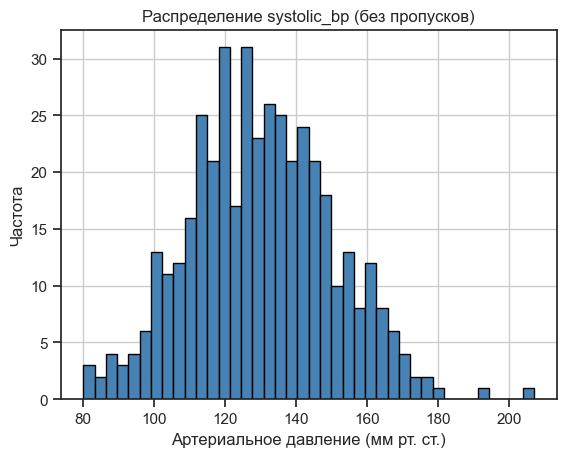

In [6]:
# Смотрим на распределение признака (без пропусков)
df['systolic_bp'].hist(bins=40, edgecolor='black', color='steelblue')
plt.title('Распределение systolic_bp (без пропусков)')
plt.xlabel('Артериальное давление (мм рт. ст.)')
plt.ylabel('Частота')
plt.show()

Распределение близко к нормальному, поэтому вычисляем хвост по формуле $mean + 3 \cdot std$.

In [7]:
# Вычисляем хвост распределения (нормальный случай)
bp_mean = df['systolic_bp'].mean()
bp_std  = df['systolic_bp'].std()
extreme_value = bp_mean + 3 * bp_std
print(f'mean = {bp_mean:.2f},  std = {bp_std:.2f}')
print(f'extreme_value = {extreme_value:.2f}')

mean = 130.16,  std = 20.13
extreme_value = 190.57


In [8]:
# Заполняем пропуски значением хвоста распределения
df_filled = df.copy()
df_filled['systolic_bp'] = df['systolic_bp'].fillna(extreme_value)

print('Пропусков после заполнения:', df_filled['systolic_bp'].isnull().sum())

Пропусков после заполнения: 0


Сравниваем распределения до и после заполнения. Заполненные значения уходят в правый хвост — они выделяются из основного облака и не смешиваются с реальными данными.

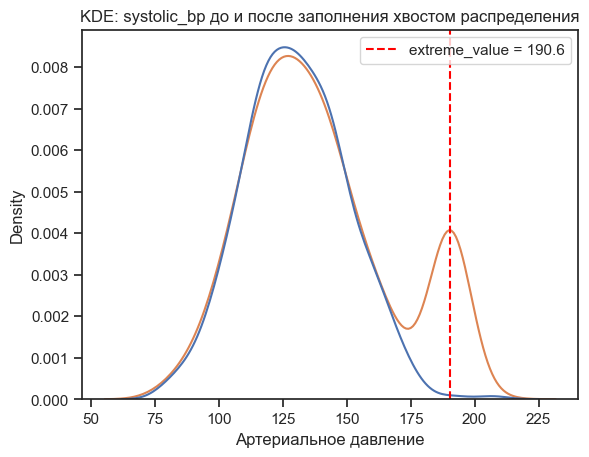

In [9]:
# Сравнение плотностей распределения до и после заполнения
compare_df = pd.DataFrame({
    'До заполнения': df['systolic_bp'],
    'После заполнения': df_filled['systolic_bp']
})
sns.kdeplot(data=compare_df)
plt.axvline(extreme_value, color='red', linestyle='--', label=f'extreme_value = {extreme_value:.1f}')
plt.title('KDE: systolic_bp до и после заполнения хвостом распределения')
plt.xlabel('Артериальное давление')
plt.legend()
plt.show()

In [10]:
# Итоговые статистики
print('Статистики ДО заполнения:')
print(df['systolic_bp'].describe())
print('\nСтатистики ПОСЛЕ заполнения:')
print(df_filled['systolic_bp'].describe())

Статистики ДО заполнения:
count    425.000000
mean     130.163424
std       20.134577
min       80.000000
25%      116.005490
50%      129.629737
75%      143.591955
max      207.054630
Name: systolic_bp, dtype: float64

Статистики ПОСЛЕ заполнения:
count    500.000000
mean     139.223983
std       28.471025
min       80.000000
25%      118.478870
50%      134.304385
75%      155.025834
max      207.054630
Name: systolic_bp, dtype: float64


**Вывод:** среднее и медиана немного сдвинулись вправо — заполненные значения явно отличаются от основного распределения. Это и есть цель метода: пропуски не «растворяются» в данных, а остаются заметными.

## Задача №29. Удаление константных и псевдоконстантных признаков

**Константный признак** — все значения одинаковы, дисперсия = 0. 
**Псевдоконстантный признак** — почти все значения одинаковы, дисперсия очень мала.

Такие признаки не несут полезной информации для модели и должны быть удалены.

Используем `VarianceThreshold` из `sklearn` — удаляет признаки, у которых дисперсия ниже заданного порога.

In [11]:
# Работаем с заполненным датасетом (без пропусков)
# Проверяем уникальные значения и дисперсию каждого признака
for col in df_filled.columns:
    n_unique = df_filled[col].nunique()
    variance = df_filled[col].var()
    print(f'{col:20s}  unique={n_unique:4d}  var={variance:.4f}')

age                   unique=  60  var=300.5363
systolic_bp           unique= 425  var=810.5992
bmi                   unique= 497  var=23.6823
glucose               unique= 500  var=1675.1965
heart_rate            unique= 497  var=135.3472
region_code           unique=   1  var=0.0000
test_version          unique=   2  var=0.0310
hospital_flag         unique=   2  var=0.0329
diagnosis             unique=   2  var=0.2128


Видим, что:
- `region_code` — 1 уникальное значение, дисперсия = 0 (**константный**)
- `test_version` и `hospital_flag` — 2 уникальных значения, но дисперсия очень мала (**псевдоконстантные**)

In [12]:
# Доля преобладающего значения для псевдоконстантных признаков
for col in ['region_code', 'test_version', 'hospital_flag']:
    top_val = df_filled[col].value_counts(normalize=True).iloc[0]
    print(f'{col}: преобладающее значение занимает {top_val:.1%}')

region_code: преобладающее значение занимает 100.0%
test_version: преобладающее значение занимает 96.8%
hospital_flag: преобладающее значение занимает 96.6%


In [13]:
# Применяем VarianceThreshold
# threshold=0.05 отсекает признаки, у которых дисперсия < 0.05
selector = VarianceThreshold(threshold=0.05)
selector.fit(df_filled)

# Дисперсия каждого признака
variances = pd.Series(selector.variances_, index=df_filled.columns)
print('Дисперсии признаков:')
print(variances.round(4))

Дисперсии признаков:
age               299.9352
systolic_bp       808.9780
bmi                23.6350
glucose          1671.8461
heart_rate        135.0766
region_code         0.0000
test_version        0.0310
hospital_flag       0.0328
diagnosis           0.2124
dtype: float64


In [14]:
# Маска: True — признак оставить, False — удалить
support = selector.get_support()
feature_status = pd.DataFrame({
    'признак': df_filled.columns,
    'дисперсия': variances.values.round(4),
    'оставить': support
})
print(feature_status.to_string(index=False))

      признак  дисперсия  оставить
          age   299.9352      True
  systolic_bp   808.9780      True
          bmi    23.6350      True
      glucose  1671.8461      True
   heart_rate   135.0766      True
  region_code     0.0000     False
 test_version     0.0310     False
hospital_flag     0.0328     False
    diagnosis     0.2124      True


In [15]:
# Признаки, которые будут удалены
removed = list(df_filled.columns[~support])
print('Удаляемые признаки:', removed)

Удаляемые признаки: ['region_code', 'test_version', 'hospital_flag']


In [16]:
# Формируем итоговый датасет без константных и псевдоконстантных признаков
df_selected = df_filled[df_filled.columns[support]].copy()
print('Размер датасета ДО отбора:', df_filled.shape)
print('Размер датасета ПОСЛЕ отбора:', df_selected.shape)
df_selected.head()

Размер датасета ДО отбора: (500, 9)
Размер датасета ПОСЛЕ отбора: (500, 6)


,age,systolic_bp,bmi,glucose,heart_rate,diagnosis
0,58,140.300954,16.590353,107.765083,46.644811,1
1,71,207.054630,35.482282,91.175097,62.883232,1
2,48,141.417810,28.055087,143.268599,82.429851,1
3,34,152.711313,26.516434,162.112654,99.689946,1
4,62,149.080035,24.275405,87.442419,75.249524,1


**Вывод:** удалены 3 признака — `region_code` (константный, дисперсия = 0), `test_version` и `hospital_flag` (псевдоконстантные). Итоговый датасет содержит только информативные признаки.

## Дополнительно. Диаграмма рассеяния

Строим диаграмму рассеяния для пары признаков `glucose` и `systolic_bp`. Точки окрашены по значению целевого признака `diagnosis`.

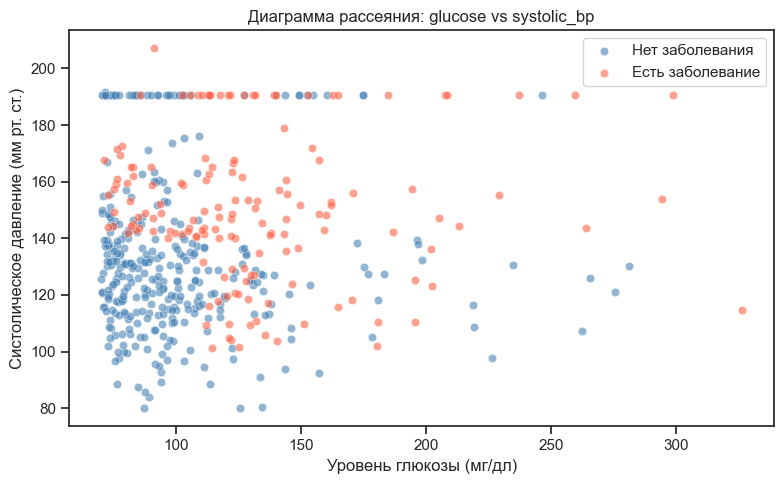

In [17]:
plt.figure(figsize=(8, 5))
colors = {0: 'steelblue', 1: 'tomato'}
labels = {0: 'Нет заболевания', 1: 'Есть заболевание'}

for cls in [0, 1]:
    mask = df_selected['diagnosis'] == cls
    plt.scatter(
        df_selected.loc[mask, 'glucose'],
        df_selected.loc[mask, 'systolic_bp'],
        c=colors[cls], label=labels[cls], alpha=0.6, edgecolors='white', linewidths=0.4
    )

plt.xlabel('Уровень глюкозы (мг/дл)')
plt.ylabel('Систолическое давление (мм рт. ст.)')
plt.title('Диаграмма рассеяния: glucose vs systolic_bp')
plt.legend()
plt.tight_layout()
plt.show()